In [ ]:
# importing respective libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers



In [3]:
# loading the data set + and read first few 
df = pd.read_csv("loan_data.csv")
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [4]:
# Task 1: Feature Transformation -- Transform categorical values into numerical values (discrete)

# --> feature transformation - categorical to numerical
df = pd.get_dummies(df, columns=['purpose'], drop_first=True)

df.head()


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,True,False,False,False,False,False


Interest rate vs default:


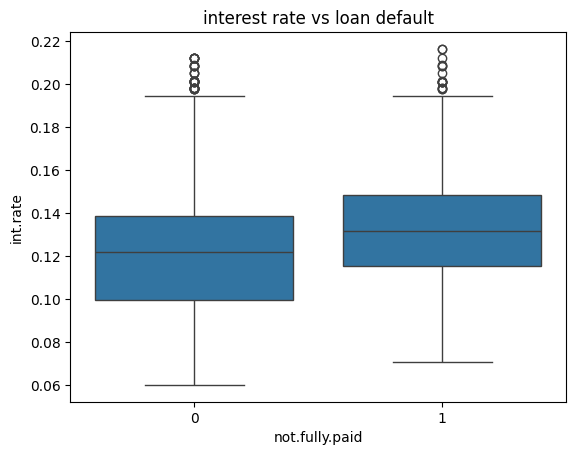


FICO score vs default:


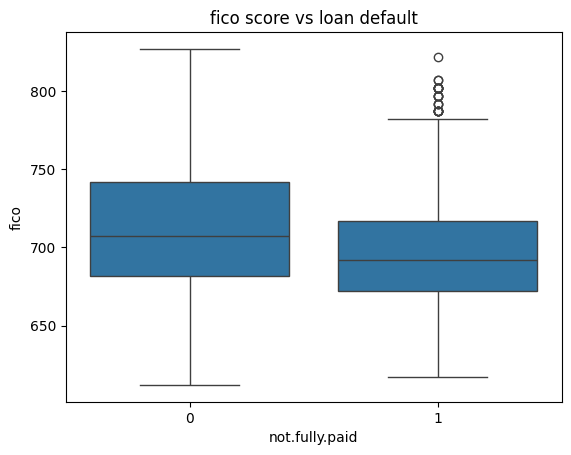


DTI vs default':


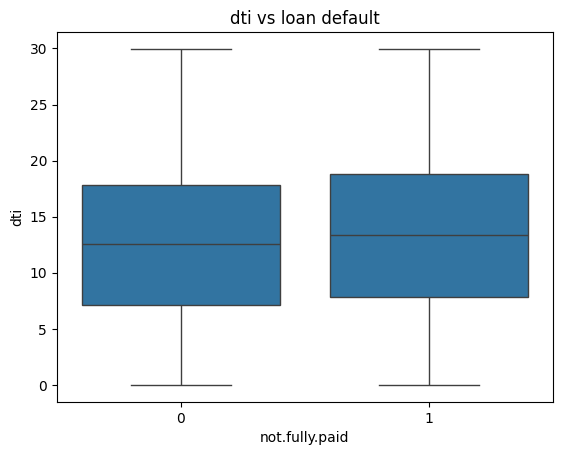

In [9]:
# Task 2: Exploratory data analysis of different factors in the dataset
# -> should show at least 3 meaningful relationships involving not.fully.paid

# Interest rate vs default
print("Interest rate vs default:")
sns.boxplot(x='not.fully.paid', y='int.rate', data=df)
plt.title('interest rate vs loan default')
plt.show()

# FICO score vs default
print("\nFICO score vs default:")
sns.boxplot(x='not.fully.paid', y='fico', data=df)
plt.title('fico score vs loan default')
plt.show()

# DTI vs default
print("\nDTI vs default':")
sns.boxplot(x='not.fully.paid', y='dti', data=df)
plt.title('dti vs loan default')
plt.show()


* Categorical variable purpose was successfully transformed into numerical features using one-hot encoding

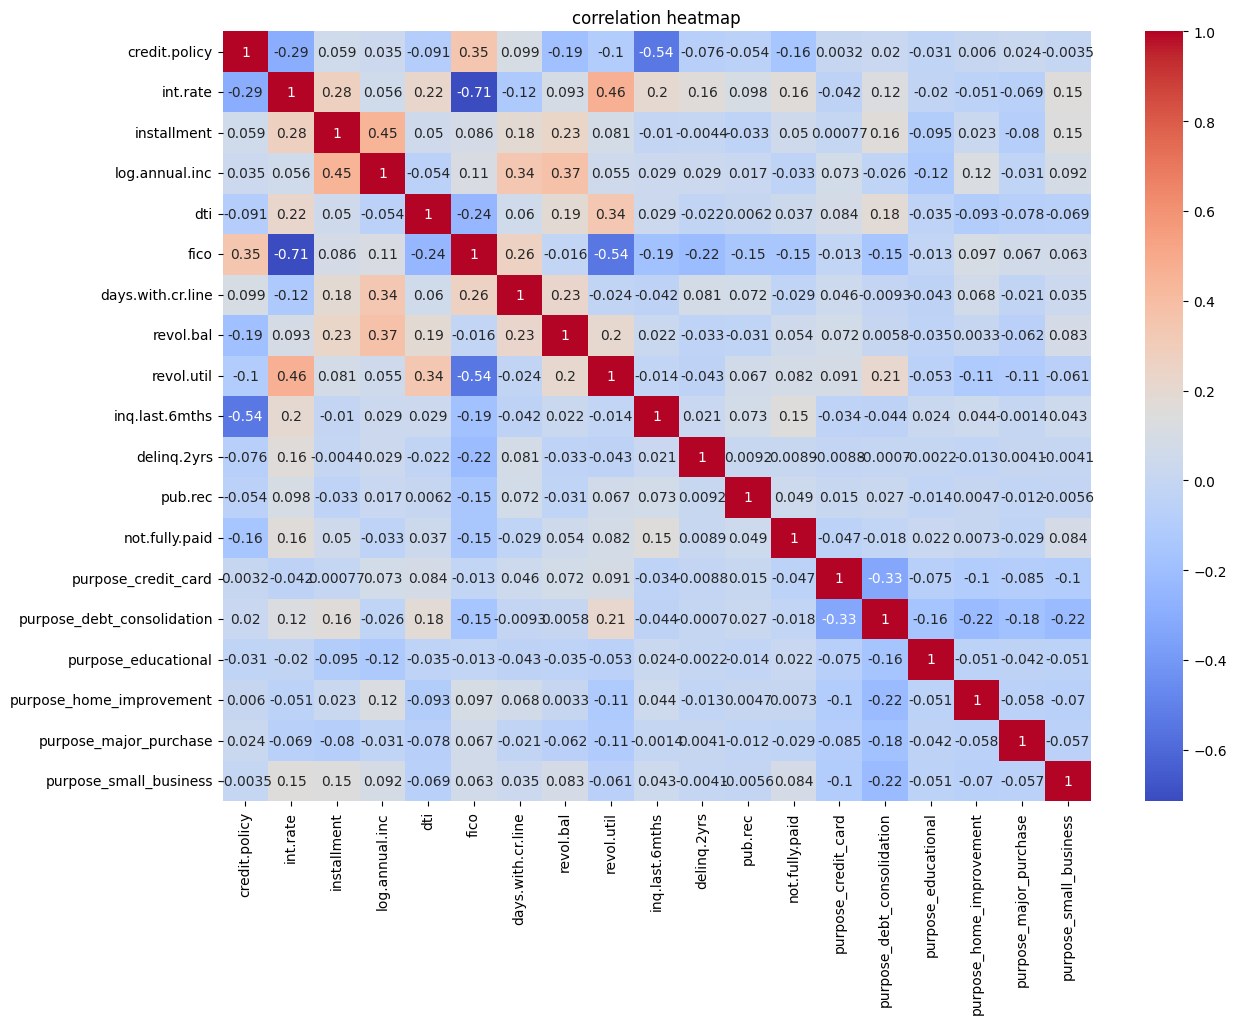

In [10]:
# Task 3: 
# -> Additional Feature Engineering
#           check the correlation between features and drop those features that have a strong correlation
#           & helps reduce the number of features and leaves us with the most relevant features



# heatmap 
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.title('correlation heatmap')
plt.show()

* Correlation analysis showed no highly correlated feature pairs; therefore, no features were removed.

In [31]:
# Task 4: Modeling
# -> build the predictive models
# -> create a deep learning model using keras with tensorflow backend

# train test split
x = df.drop("not.fully.paid", axis=1)
y = df["not.fully.paid"].astype(int)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# feature scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# fixed validation split (so it doesn't change each run)
x_train2, x_val, y_train2, y_val = train_test_split(
    x_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# create model -> sequential
model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(x_train2.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    #metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy")]
    metrics=["accuracy"]
)
print(model.metrics_names)

# train model (use scaled + fixed validation set)
history = model.fit(
    x_train2, y_train2,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

# evaluate model (use scaled test set)
results = model.evaluate(x_test_scaled, y_test, verbose=0)

for name, value in zip(model.metrics_names, results):
    if name == "compile_metrics":
        name = "accuracy"
    print(f"{name}: {value:.4f}")




['loss', 'compile_metrics']
Epoch 1/20


/Users/angelajohnson/miniforge3/envs/tfarm/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 895us/step - accuracy: 0.8349 - loss: 0.4400 - val_accuracy: 0.8402 - val_loss: 0.4224
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step - accuracy: 0.8401 - loss: 0.4121 - val_accuracy: 0.8402 - val_loss: 0.4190
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step - accuracy: 0.8406 - loss: 0.4068 - val_accuracy: 0.8297 - val_loss: 0.4238
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - accuracy: 0.8396 - loss: 0.4045 - val_accuracy: 0.8395 - val_loss: 0.4199
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - accuracy: 0.8412 - loss: 0.4003 - val_accuracy: 0.8356 - val_loss: 0.4173
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.8416 - loss: 0.3983 - val_accuracy: 0.8363 - val_loss: 0.4206
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.8417 - loss: 0.3963 - val_accuracy: 0.8376 - val_loss: 0.4179
Epoch 8/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.8412 - loss: 0.3949 - val_accurac

* This deep learning model predicts loan repayment risk with ~83% accuracy, offering a reliable and scalable way to support lending decisions and reduce default risk.